## Multivariate LSTM — Joint Forecasting

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

In [2]:
# Load the CSV file into a DataFrame

df = pd.read_csv('finalNew.csv')

# View the first 5 rows
print(df.head())
df

       Date_x      Close       High        Low       Open     Volume  \
0  2023-05-01  28.818560  28.966092  27.692135  27.751944  570329000   
1  2023-06-01  39.644203  39.923316  38.218726  38.367253  635873000   
2  2023-07-03  42.283222  42.766739  42.072869  42.386904  198209000   
3  2023-08-01  46.364693  46.756492  45.886162  46.317836  237858000   
4  2023-09-01  48.360565  49.647615  47.994688  49.609733  463830000   

     Close_l    Close_2  Rolling_mean_3_x  Rolling_std_3_x  ...  return_y  \
0  27.661232  27.139885         27.873226         0.859182  ... -0.191382   
1  37.714336  39.984123         39.114221         1.224191  ...  0.144186   
2  42.172554  40.697086         41.717621         0.885539  ... -0.063589   
3  46.586018  46.606956         46.519222         0.134235  ... -0.126332   
4  49.203987  49.113262         48.892605         0.462987  ...  0.097744   

   Year_y  Month_y  Log_Close Log_Value boxcox_Close  Diff_Close  Diff_Value  \
0    2023        5   3.3

,Date_x,Close,High,Low,Open,Volume,Close_l,Close_2,Rolling_mean_3_x,Rolling_std_3_x,...,return_y,Year_y,Month_y,Log_Close,Log_Value,boxcox_Close,Diff_Close,Diff_Value,Seasonal_Diff_Close,Seasonal_Diff_Value
0,2023-05-01,28.818560,28.966092,27.692135,27.751944,570329000,27.661232,27.139885,27.873226,0.859182,...,-0.191382,2023,5,3.361020,2.297170,6.303270,0.942011,1.140,9.365526,-2.664
1,2023-06-01,39.644203,39.923316,38.218726,38.367253,635873000,37.714336,39.984123,39.114221,1.224191,...,0.144186,2023,6,3.679945,2.509599,7.366221,10.825644,2.354,21.399199,0.200
2,2023-07-03,42.283222,42.766739,42.072869,42.386904,198209000,42.172554,40.697086,41.717621,0.885539,...,-0.063589,2023,7,3.744390,2.374906,7.595449,2.639019,-1.550,27.816617,-0.050
3,2023-08-01,46.364693,46.756492,45.886162,46.317836,237858000,46.586018,46.606956,46.519222,0.134235,...,-0.126332,2023,8,3.836538,2.440606,7.932109,4.081470,0.730,27.995302,-0.040
4,2023-09-01,48.360565,49.647615,47.994688,49.609733,463830000,49.203987,49.113262,48.892605,0.462987,...,0.097744,2023,9,3.878685,2.575661,8.089660,1.995872,1.660,34.477687,-0.630
5,2023-10-02,44.648651,45.040479,43.730392,43.898888,433298000,43.369469,42.960697,43.659606,0.880586,...,-0.108712,2023,10,3.798824,2.482404,7.793038,-3.711914,-1.170,32.181533,0.280
6,2023-11-01,42.198971,42.254804,40.747305,40.762260,437593000,40.658569,41.038437,41.298659,0.802494,...,-0.021850,2023,11,3.742396,2.597491,7.588279,-2.449680,1.460,28.704551,2.370
7,2023-12-01,46.625744,47.059450,46.049466,46.386461,369317000,46.630733,47.996651,47.084376,0.790057,...,0.170503,2023,12,3.842153,2.619583,7.952966,4.426773,0.300,29.547842,2.270
8,2024-01-02,48.028790,49.152531,47.457447,49.101680,411254000,49.378883,49.378883,48.928852,0.779477,...,-0.041667,2024,1,3.871801,2.462150,8.063770,1.403046,-2.000,33.761492,2.727
9,2024-02-01,62.844852,63.008380,61.471833,61.920530,369146000,61.349186,62.592579,62.262206,0.800696,...,-0.148225,2024,2,4.140669,2.504709,9.121589,14.816063,0.510,41.971640,2.845


In [3]:
features = df[['Close',
    'Value',
    'Rolling_mean_3_x',
    'Rolling_mean_3_y']].dropna()

In [4]:
from sklearn.preprocessing import MinMaxScaler

In [5]:
scaler = MinMaxScaler()
scaler_data = scaler.fit_transform(features)
scaler_data

array([[0.        , 0.        , 0.        , 0.        ],
       [0.06096653, 0.07679259, 0.06396901, 0.01549902],
       [0.07582864, 0.02622822, 0.07878414, 0.0239861 ],
       [0.09881416, 0.05004241, 0.10610856, 0.03631257],
       [0.11005427, 0.10419521, 0.11961474, 0.05601471],
       [0.08914997, 0.06602727, 0.08983537, 0.06197587],
       [0.07535416, 0.11365564, 0.07639996, 0.05955099],
       [0.10028432, 0.12344229, 0.10932468, 0.04752763],
       [0.10818582, 0.05819795, 0.11982102, 0.05399398],
       [0.19162511, 0.07483526, 0.19569698, 0.06207691],
       [0.29973279, 0.14432048, 0.29353228, 0.08784125],
       [0.34515155, 0.08429569, 0.35392081, 0.11451492],
       [0.30403354, 0.15802179, 0.32787664, 0.13361085],
       [0.48350459, 0.23044301, 0.47528715, 0.16846849],
       [0.53578773, 0.14595159, 0.54475744, 0.18928203],
       [0.45104034, 0.27056828, 0.46555366, 0.23282882],
       [0.44424479, 0.29764468, 0.49392855, 0.25778487],
       [0.49484619, 0.28655314,

In [14]:
X = []
y =[]

window_size  = 12

for i in range(window_size,len(scaler_data)):
    X.append(scaler_data[i-window_size:i])
    y.append(scaler_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(23, 12, 4)
(23, 4)


In [15]:
model = Sequential([
    Input((X.shape[1], X.shape[2])),
    LSTM(64, activation='tanh'),
    Dense(32 , activation='relu')
])

In [16]:
model.add(Dense(4))

In [17]:
model.compile(
    optimizer='adam',
    loss='mse')

In [18]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 64)                  │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,876 (77.64 KB)

 Trainable params: 19,876 (77.64 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X,
    y,
    epochs=50,
    batch_size=16,
    validation_split=0.2)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - loss: 0.0075 - val_loss: 0.0541
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0075 - val_loss: 0.0542
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0075 - val_loss: 0.0541
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0075 - val_loss: 0.0539
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0074 - val_loss: 0.0536
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0074 - val_loss: 0.0534
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0074 - val_loss: 0.0532
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0074 - val_loss: 0.0532
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0074 - val_loss: 0.0532
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0074 - val_loss: 0.0531
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0074 - val_loss: 0.0530
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0074 - val_loss: 0.0528

In [23]:
# 7. Make Predictions
import matplotlib.pyplot as plt
predictions = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [24]:
predictions

array([[0.3311743 , 0.16196206, 0.3447184 , 0.14412192],
       [0.35653725, 0.17808133, 0.36930287, 0.15753525],
       [0.3987871 , 0.20878756, 0.40819478, 0.18035343],
       [0.43682772, 0.23576778, 0.4465698 , 0.20276225],
       [0.47029606, 0.25726995, 0.47898585, 0.2206974 ],
       [0.50014025, 0.27695048, 0.5087295 , 0.2378098 ],
       [0.52967614, 0.29691622, 0.53934157, 0.2551628 ],
       [0.5669241 , 0.32060575, 0.5755395 , 0.27457035],
       [0.5977545 , 0.337344  , 0.6065861 , 0.28949574],
       [0.61446685, 0.3448118 , 0.62791055, 0.2994701 ],
       [0.61911005, 0.34152997, 0.63660234, 0.30079007],
       [0.6251254 , 0.34161726, 0.6435245 , 0.30235288],
       [0.6160706 , 0.33362356, 0.6394873 , 0.29869282],
       [0.6170277 , 0.3349511 , 0.6420344 , 0.29960772],
       [0.6360645 , 0.35304132, 0.6576629 , 0.31118774],
       [0.6626135 , 0.37773386, 0.6814503 , 0.32846642],
       [0.69942665, 0.4087903 , 0.7144232 , 0.35113186],
       [0.7357609 , 0.4362473 ,

In [27]:
scaler.inverse_transform(y)

array([[ 82.80487823,  14.79      ,  85.48956299,  15.40666667],
       [114.67301178,  17.01      , 111.39337158,  16.55666667],
       [123.95677185,  14.42      , 123.60108439,  17.24333333],
       [108.90843201,  18.24      , 109.68294779,  18.68      ],
       [107.70176697,  19.07      , 114.66914368,  19.50333333],
       [116.68690491,  18.73      , 119.6256841 ,  20.24333333],
       [135.03765869,  20.71      , 135.46983846,  19.55      ],
       [138.25904846,  21.29      , 137.03897095,  18.65666667],
       [137.94937134,  16.65      , 136.34025065,  18.46333333],
       [116.35582733,  18.03      , 120.14591726,  18.27666667],
       [113.76260376,  20.71      , 119.39787292,  18.45666667],
       [109.87290192,  16.09      , 109.12478892,  18.47666667],
       [111.32923126,  18.57      , 109.57365672,  20.07      ],
       [137.03442383,  20.77      , 136.88811239,  21.02      ],
       [152.92498779,  20.87      , 155.96419779,  22.48      ],
       [173.29502869,  21

In [29]:
# Inverse transform predictions back to original scale
predictions_inverse = scaler.inverse_transform(predictions)
y_test_inverse = scaler.inverse_transform(y)

In [25]:
scaler.inverse_transform(predictions)

array([[ 87.62418 ,  14.910785,  88.4491  ,  15.753441],
       [ 92.12781 ,  15.404904,  92.76922 ,  16.195965],
       [ 99.62999 ,  16.346174,  99.60352 ,  16.948767],
       [106.38474 ,  17.173225, 106.347   ,  17.688063],
       [112.327614,  17.832354, 112.04333 ,  18.279768],
       [117.62695 ,  18.43564 , 117.27006 ,  18.84433 ],
       [122.87155 ,  19.04767 , 122.649376,  19.416828],
       [129.48557 ,  19.773848, 129.01028 ,  20.057108],
       [134.96002 ,  20.286942, 134.46597 ,  20.549517],
       [137.92758 ,  20.51586 , 138.21323 ,  20.878584],
       [138.75206 ,  20.415258, 139.74059 ,  20.92213 ],
       [139.82019 ,  20.417936, 140.957   ,  20.973692],
       [138.21236 ,  20.172897, 140.24756 ,  20.85294 ],
       [138.38231 ,  20.21359 , 140.69514 ,  20.883125],
       [141.76262 ,  20.76813 , 143.44148 ,  21.265165],
       [146.47684 ,  21.525055, 147.62154 ,  21.83521 ],
       [153.01364 ,  22.477057, 153.41571 ,  22.582973],
       [159.46541 ,  23.318724,

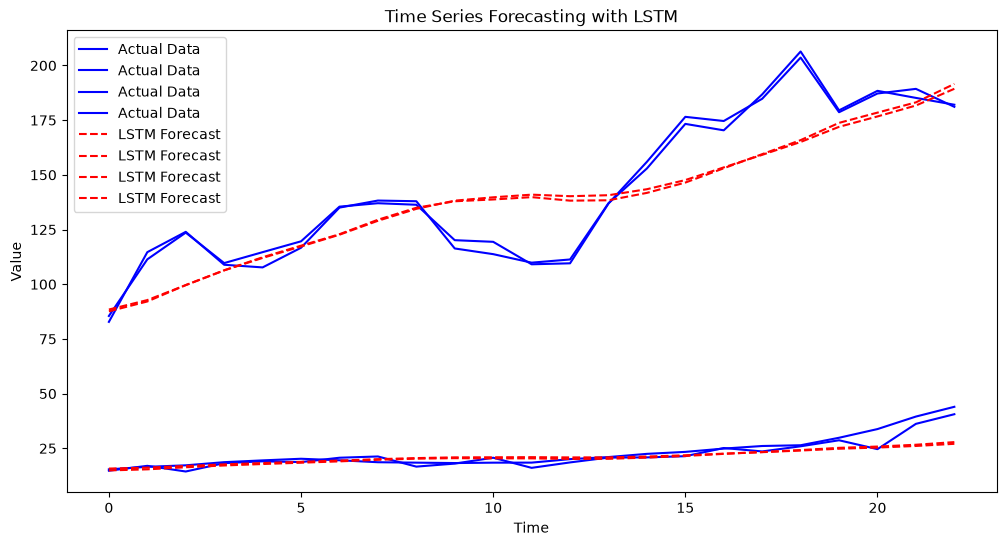

In [30]:
# 8. Plot the Results
plt.figure(figsize=(12, 6))
plt.plot( y_test_inverse, label='Actual Data', color='blue')
plt.plot(predictions_inverse, label='LSTM Forecast', color='red', linestyle='--')
plt.title('Time Series Forecasting with LSTM')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()